# Preet's Evaluation

# Model Evaluation for all three Models

## Comparsion between all three models

In [43]:
from tensorflow.keras.models import load_model

model1 = load_model("vgg16_tl_best.h5")
model2 = load_model("vgg16_finetune_best.h5")
model3 = load_model("vgg16_tune3_best.h5")

## Function for Evaluation

In [44]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

def evaluate_model(model, test_gen, class_names):
    test_gen.reset()
    y_pred_prob = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = test_gen.classes
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
    roc_auc_val = auc(fpr, tpr)
    return acc, report, cm, fpr, tpr, roc_auc_val, y_pred, y_true, y_pred_prob, y_true_bin

## Evaluate All Models

In [45]:
class_names = ['drink', 'food', 'inside', 'menu', 'outside']

results = []
for i, m in enumerate([model1, model2, model3], 1):
    print(f"\nEvaluating Model {i} ...")
    results.append(evaluate_model(m, test_gen, class_names))

# Unpacking the results for clarity
(acc1, report1, cm1, fpr1, tpr1, auc1, y_pred1, y_true1, prob1, bin1) = results[0]
(acc2, report2, cm2, fpr2, tpr2, auc2, y_pred2, y_true2, prob2, bin2) = results[1]
(acc3, report3, cm3, fpr3, tpr3, auc3, y_pred3, y_true3, prob3, bin3) = results[2]


Evaluating Model 1 ...
625/625 ━━━━━━━━━━━━━━━━━━━━ 523s 836ms/step

Evaluating Model 2 ...
625/625 ━━━━━━━━━━━━━━━━━━━━ 488s 780ms/step

Evaluating Model 3 ...
625/625 ━━━━━━━━━━━━━━━━━━━━ 544s 869ms/step


## Print Accuracy & Classification Reports

In [46]:
print(f"\nModel 1 (Frozen)   Accuracy: {acc1*100:.2f}%")
print(f"Model 2 (Unfreeze4) Accuracy: {acc2*100:.2f}%")
print(f"Model 3 (Unfreeze8) Accuracy: {acc3*100:.2f}%")

print("\nModel 1 Classification Report")
print(classification_report(y_true1, y_pred1, target_names=class_names))

print("\nModel 2 Classification Report")
print(classification_report(y_true2, y_pred2, target_names=class_names))

print("\nModel 3 Classification Report")
print(classification_report(y_true3, y_pred3, target_names=class_names))


Model 1 (Frozen)   Accuracy: 73.34%
Model 2 (Unfreeze4) Accuracy: 84.28%
Model 3 (Unfreeze8) Accuracy: 86.14%

Model 1 Classification Report
              precision    recall  f1-score   support

       drink       0.74      0.58      0.65      1000
        food       0.78      0.87      0.83      1000
      inside       0.65      0.61      0.63      1000
        menu       0.82      0.88      0.85      1000
     outside       0.66      0.72      0.69      1000

    accuracy                           0.73      5000
   macro avg       0.73      0.73      0.73      5000
weighted avg       0.73      0.73      0.73      5000


Model 2 Classification Report
              precision    recall  f1-score   support

       drink       0.80      0.80      0.80      1000
        food       0.85      0.94      0.89      1000
      inside       0.79      0.74      0.76      1000
        menu       0.95      0.92      0.93      1000
     outside       0.84      0.82      0.83      1000

    accuracy

## Side-by-Side Confusion Matrixs

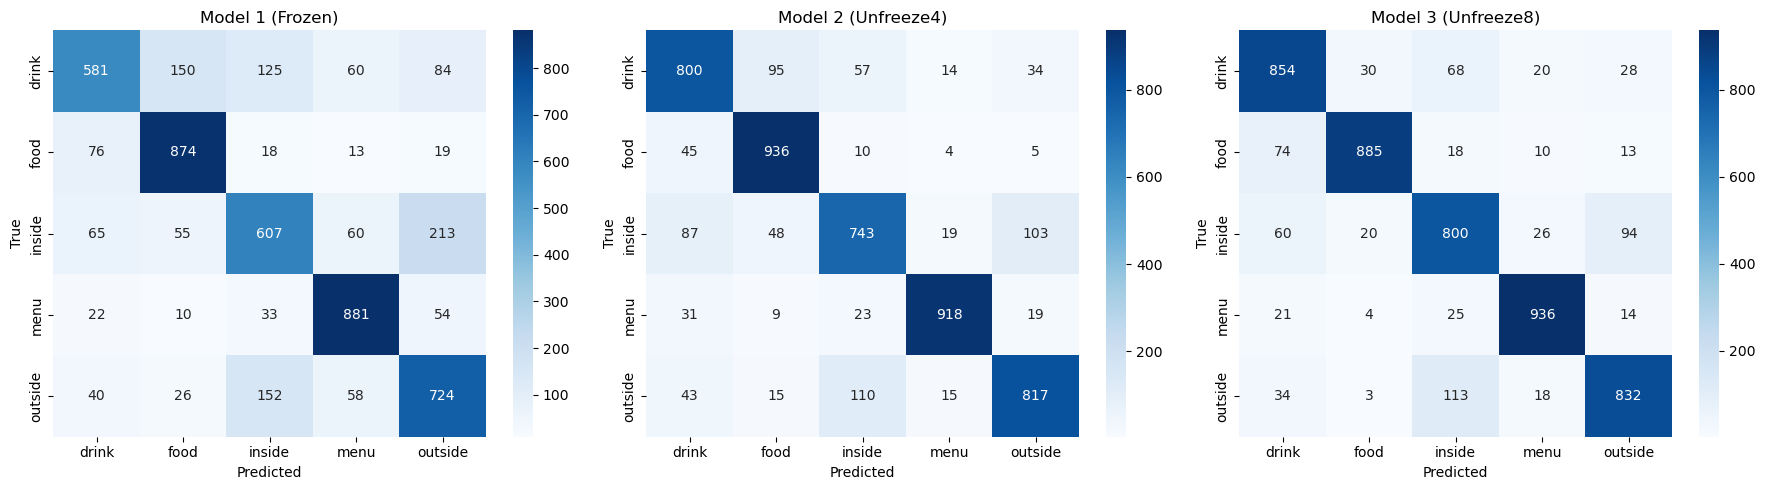

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,5))
for i, (cm, title) in enumerate(zip([cm1, cm2, cm3], 
         ["Model 1 (Frozen)", "Model 2 (Unfreeze4)", "Model 3 (Unfreeze8)"]), 1):
    plt.subplot(1, 3, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
plt.tight_layout()
plt.show()

## Plot ROC Curves & Print AUC

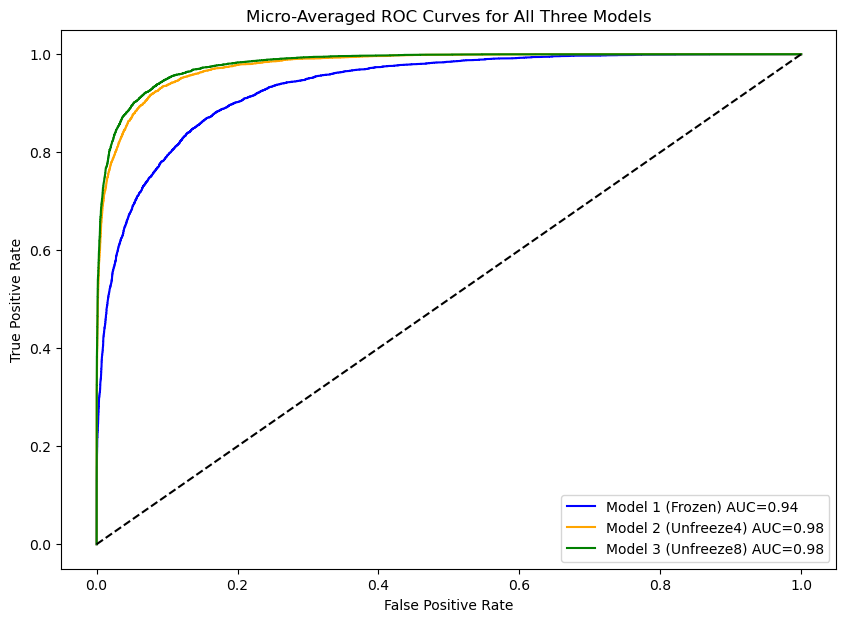


Model 1 (Frozen)   Micro-Averaged AUC: 0.9351
Model 2 (Unfreeze4) Micro-Averaged AUC: 0.9775
Model 3 (Unfreeze8) Micro-Averaged AUC: 0.9814


In [48]:
plt.figure(figsize=(10,7))
plt.plot(fpr1, tpr1, label=f'Model 1 (Frozen) AUC={auc1:.2f}', color='blue')
plt.plot(fpr2, tpr2, label=f'Model 2 (Unfreeze4) AUC={auc2:.2f}', color='orange')
plt.plot(fpr3, tpr3, label=f'Model 3 (Unfreeze8) AUC={auc3:.2f}', color='green')
plt.plot([0,1],[0,1],'k--')
plt.title("Micro-Averaged ROC Curves for All Three Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print(f"\nModel 1 (Frozen)   Micro-Averaged AUC: {auc1:.4f}")
print(f"Model 2 (Unfreeze4) Micro-Averaged AUC: {auc2:.4f}")
print(f"Model 3 (Unfreeze8) Micro-Averaged AUC: {auc3:.4f}")

## Random Selection of Image from Test Set

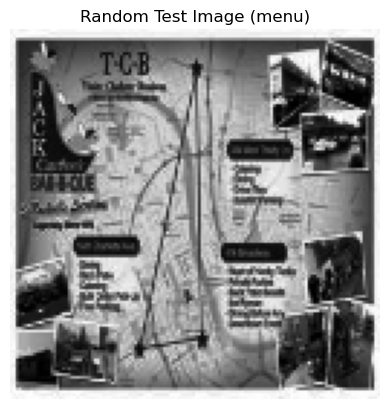

In [57]:
import random
import matplotlib.pyplot as plt

idx = random.randint(0, len(test_df) - 1)
img_path = test_df.iloc[idx]['filename']
img = plt.imread(img_path)
img_resized = tf.image.resize(img, (128,128)).numpy() / 255.0  

plt.imshow(img_resized)
plt.title(f"Random Test Image ({test_df.iloc[idx]['class']})")
plt.axis('off')
plt.show()

## LIME

In [58]:
pip install lime

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 944ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 910ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 804ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 937ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 869ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 909ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 998ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 942ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 803ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 894ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 858ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 804ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 770ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 972ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 944ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 913ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 968ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 973ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/

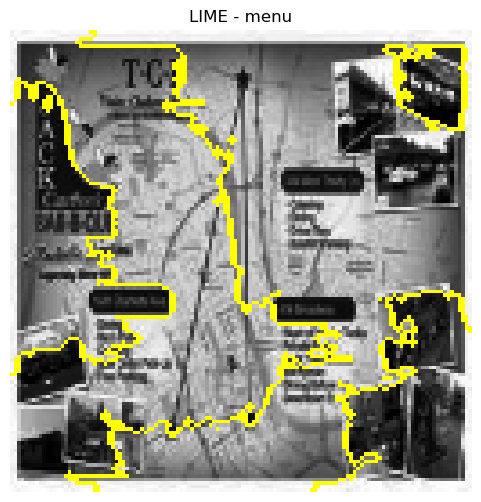

In [59]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np

def batch_predict(images):
    images = np.array(images)
    return model.predict(images)

explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    img_resized.astype('double'),
    batch_predict,
    top_labels=5,
    hide_color=0,
    num_samples=1000
)

# LIME for predicted class
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],
    positive_only=True,
    num_features=8,
    hide_rest=False
)
plt.figure(figsize=(6,6))
plt.title(f"LIME - {class_names[explanation.top_labels[0]]}")
plt.imshow(mark_boundaries(temp, mask))
plt.axis('off')
plt.show()

## Shap

In [60]:
pip install shap

  Using cached shap-0.47.2-cp312-cp312-win_amd64.whl.metadata (25 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.47.2-cp312-cp312-win_amd64.whl (545 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Note: you may need to restart the kernel to use updated packages.


len(shap_values): 1
shape: [(128, 128, 3, 5)]


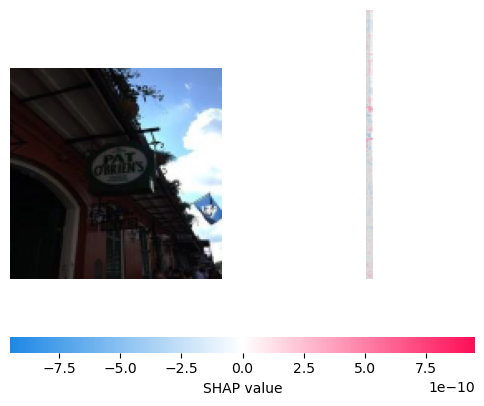

In [63]:
import shap
import random
import matplotlib.pyplot as plt

# Select a random image
idx = random.randint(0, len(test_df)-1)
img_path = test_df.iloc[idx]['filename']
img = plt.imread(img_path)
img_resized = tf.image.resize(img, (128,128)).numpy() / 255.0

sample_img = np.expand_dims(img_resized, axis=0)

# Background for SHAP
bg_idxs = random.sample(range(len(train_df)), 10)
background = []
for i in bg_idxs:
    img_bg = plt.imread(train_df.iloc[i]['filename'])
    img_bg = tf.image.resize(img_bg, (128,128)).numpy() / 255.0
    background.append(img_bg)
background = np.stack(background)

# SHAP explanation
explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(sample_img)

print("len(shap_values):", len(shap_values))
print("shape:", [np.shape(x) for x in shap_values])

# Plot SHAP for predicted class
if len(shap_values) > 1:
    pred_class = np.argmax(model.predict(sample_img))
    shap.image_plot([shap_values[pred_class]], sample_img)
else:
    shap.image_plot([shap_values[0]], sample_img)

## LLM Prompts
- how to import prepared model
- how do i evaluate model
- what are steps of lime and shap